<a href="https://colab.research.google.com/github/tien10022001/txldl/blob/main/lab3txldl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   chieu_cao_cm     100 non-null    float64
 1   can_nang_kg      100 non-null    float64
 2   toc_do_100m_s    100 non-null    float64
 3   so_ban_thang     100 non-null    int64  
 4   so_phut_thi_dau  100 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 4.0 KB
None
chieu_cao_cm       0
can_nang_kg        0
toc_do_100m_s      0
so_ban_thang       0
so_phut_thi_dau    0
dtype: int64
       chieu_cao_cm  can_nang_kg  toc_do_100m_s  so_ban_thang  so_phut_thi_dau
count    100.000000   100.000000     100.000000    100.000000       100.000000
mean     174.231290    70.334569      12.135328     14.780000      1437.440000
std       10.462542    14.305034       2.193551      8.046054       835.458494
min      148.802549    41.218432       5.000000      1.000000        48.000000
25%    

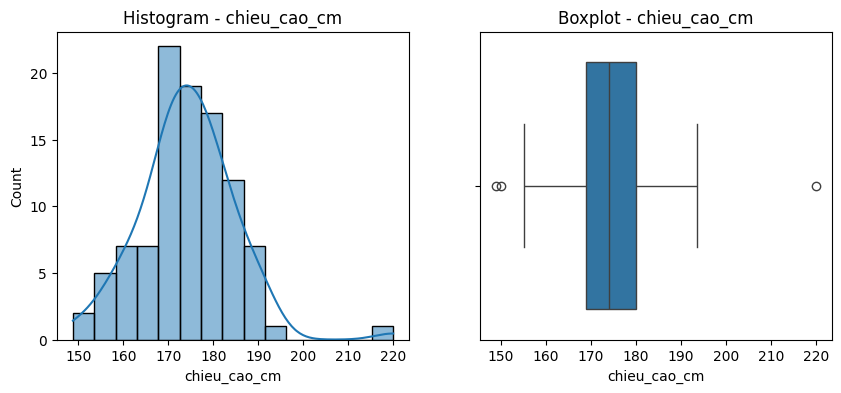

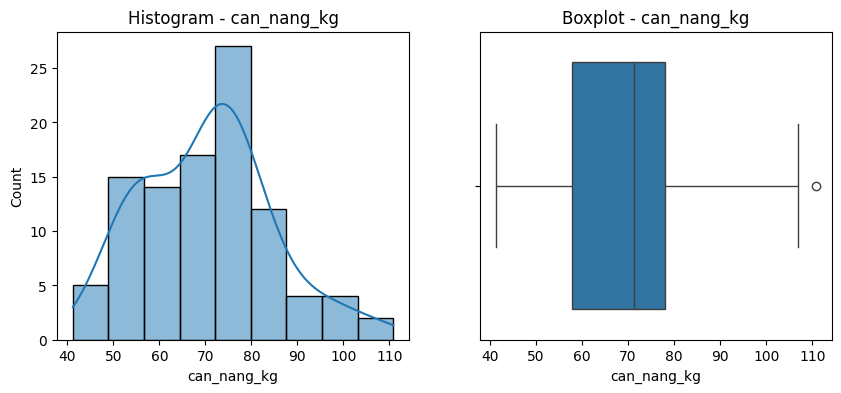

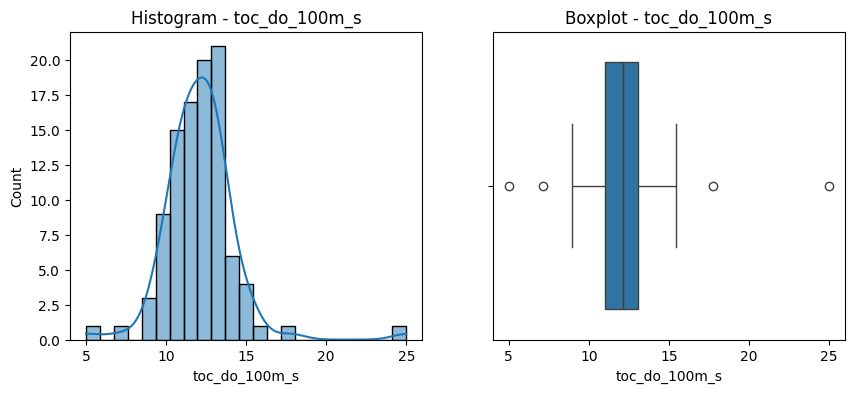

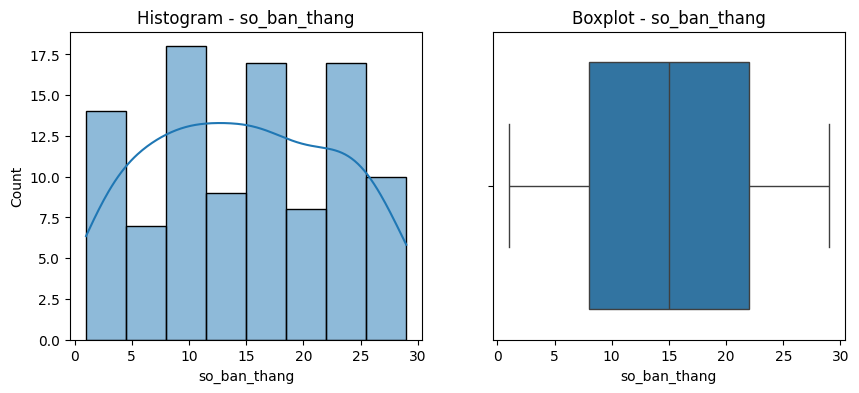

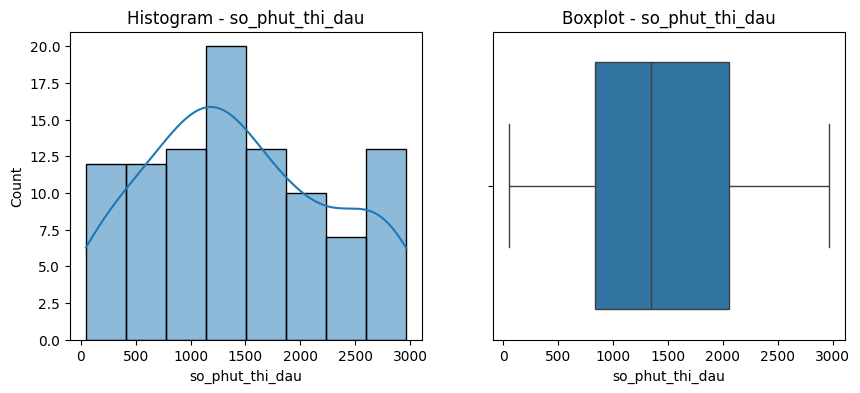

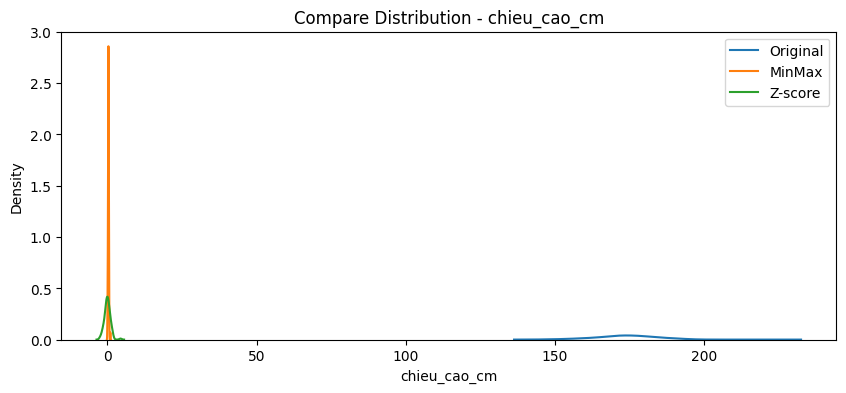

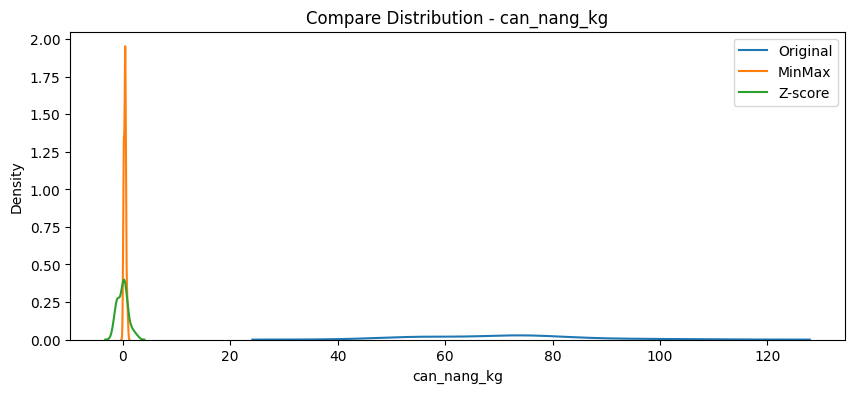

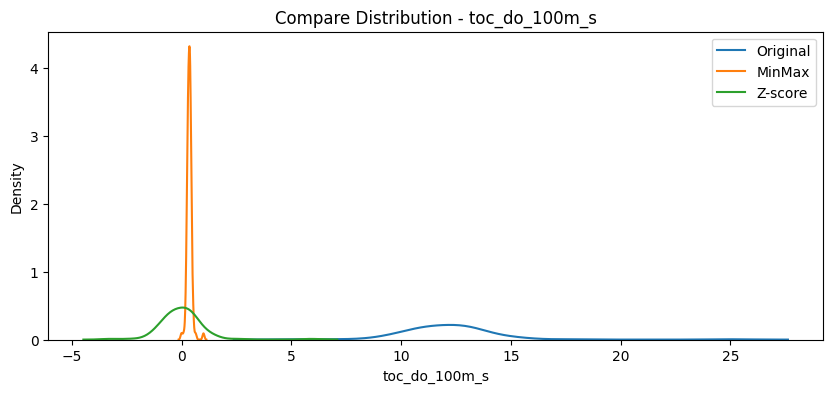

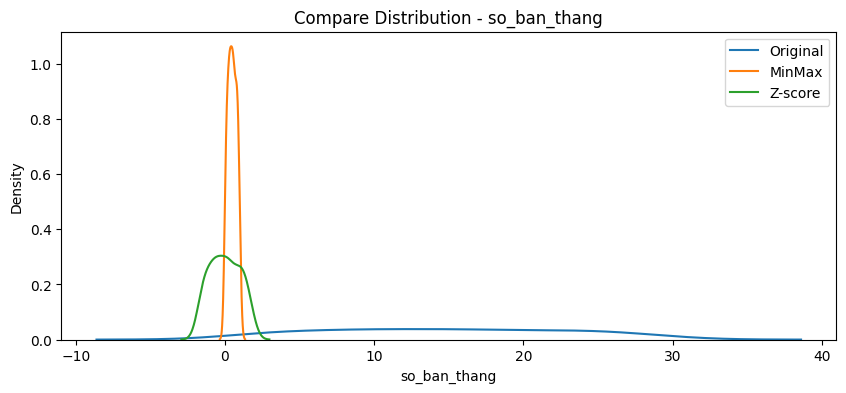

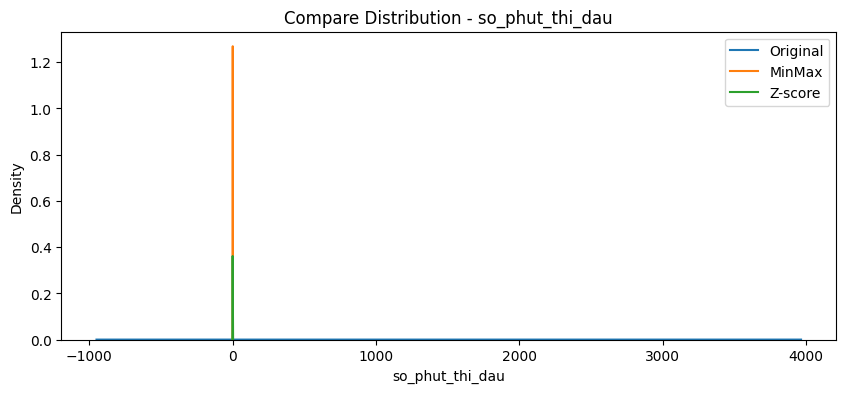

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   BMI                100 non-null    float64
 1   huyet_ap_mmHg      100 non-null    float64
 2   nhip_tim_bpm       100 non-null    float64
 3   cholesterol_mg_dl  100 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB
None
              BMI  huyet_ap_mmHg  nhip_tim_bpm  cholesterol_mg_dl
count  100.000000     100.000000    100.000000         100.000000
mean    23.967027     119.264104     70.280135         199.804870
std      5.238193      19.347547     10.599687          29.258869
min     10.000000      82.925332     43.031134         137.542118
25%     20.224820     107.918865     64.464403         178.709188
50%     23.696402     118.336822     69.564759         203.543562
75%     26.769769     128.100339     77.226957         218.357696
max     50.000000     250.000000    

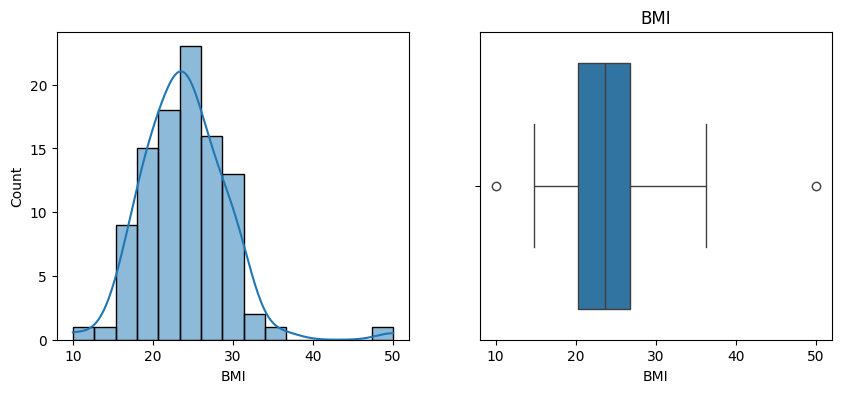

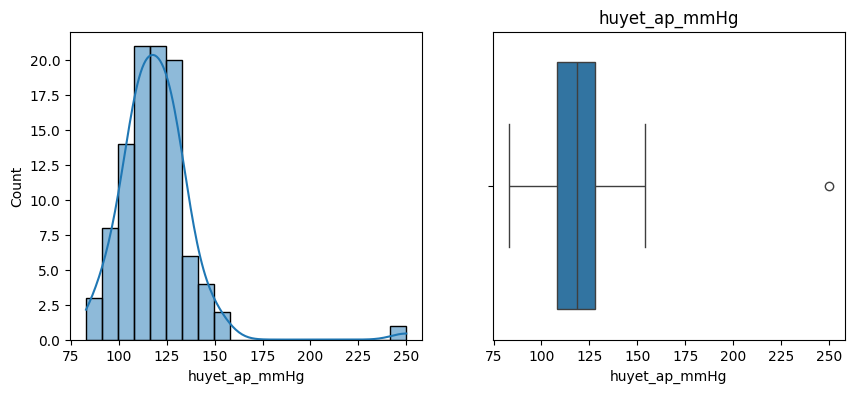

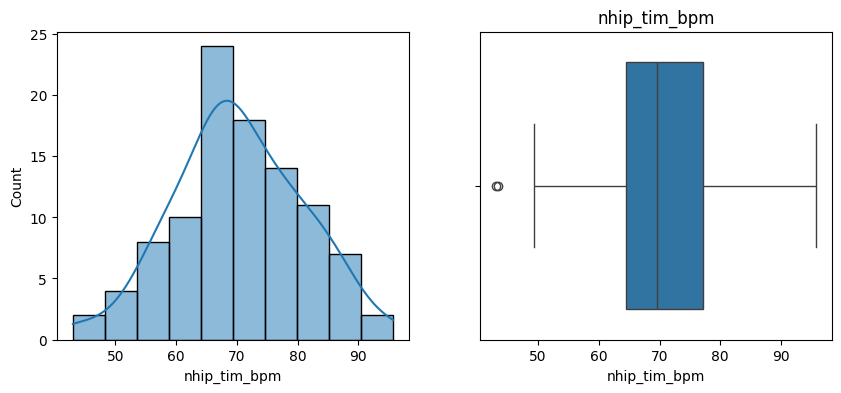

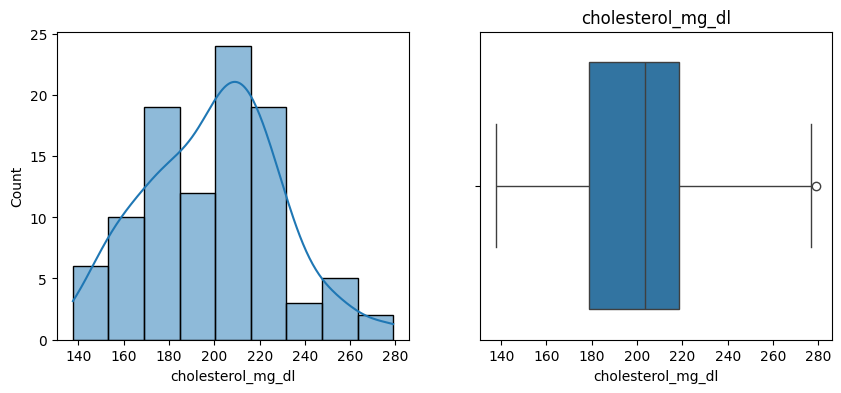

BMI: 2 outliers
huyet_ap_mmHg: 1 outliers
nhip_tim_bpm: 2 outliers
cholesterol_mg_dl: 1 outliers


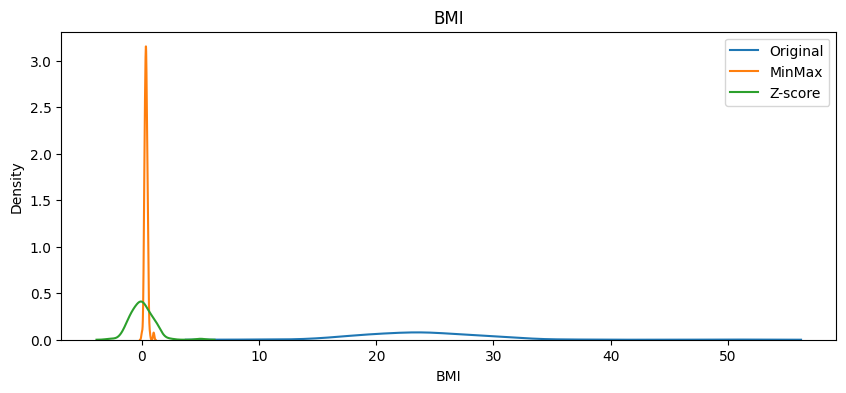

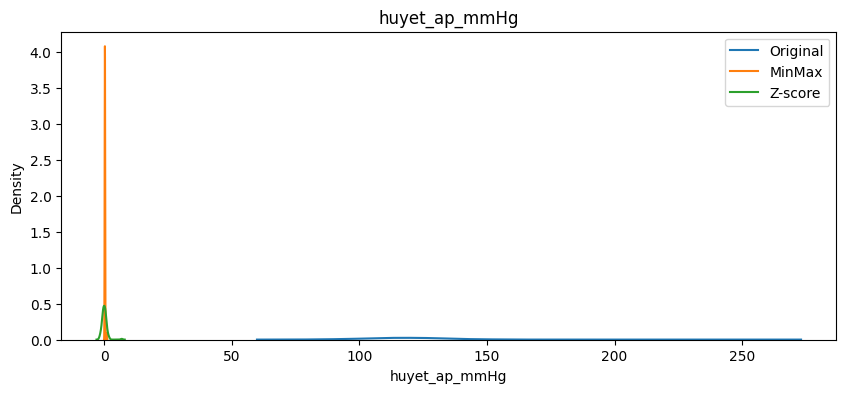

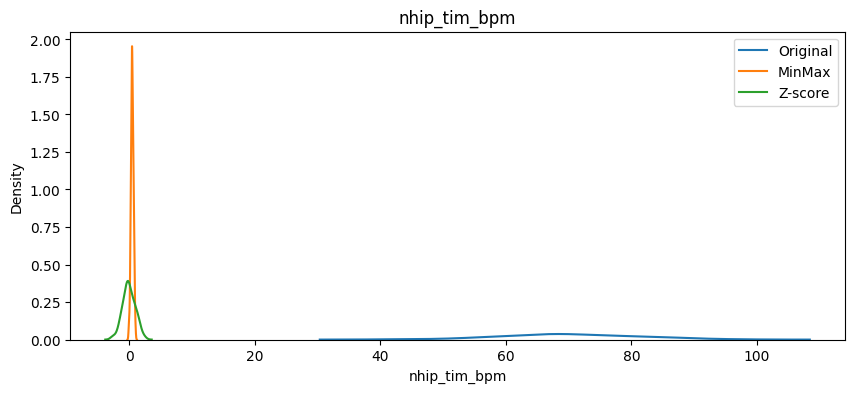

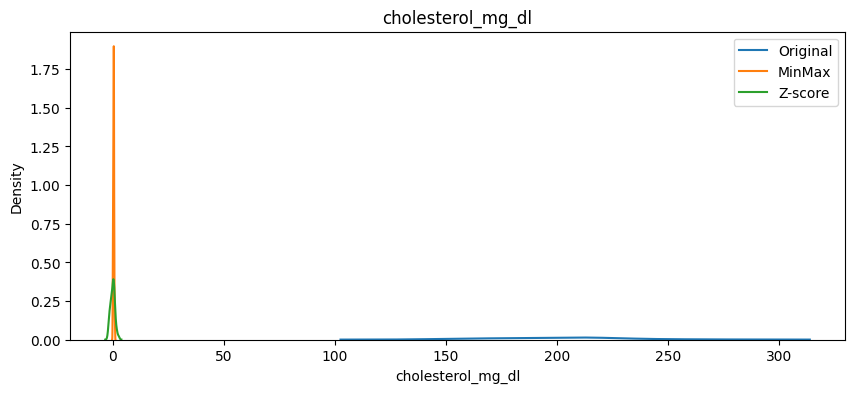

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   doanh_thu_musd  100 non-null    float64
 1   loi_nhuan_musd  100 non-null    float64
 2   so_nhan_vien    100 non-null    int64  
 3   EPS             100 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 3.3 KB
None
       doanh_thu_musd  loi_nhuan_musd  so_nhan_vien         EPS
count      100.000000      100.000000    100.000000  100.000000
mean       674.642882       56.903082    987.750000    1.982097
std       1058.779862       53.352990    601.387275    1.121290
min        196.851177      -22.716380     16.000000   -0.455125
25%        396.215304       34.539784    460.250000    1.319709
50%        517.840477       55.665623    956.500000    1.988484
75%        680.358810       71.549486   1429.500000    2.719773
max      10000.000000      500.000000   1999.000000    4.946

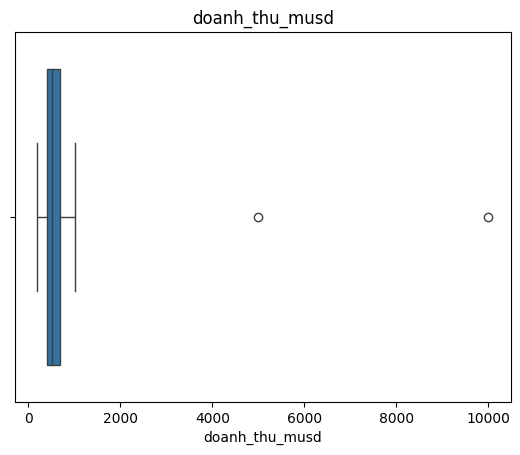

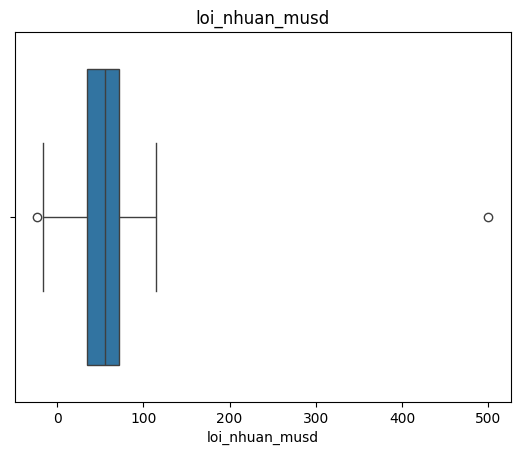

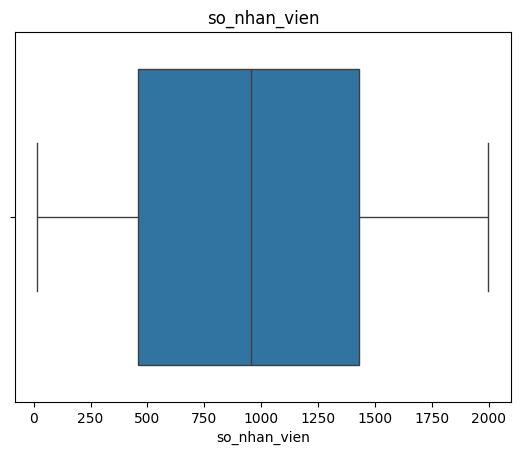

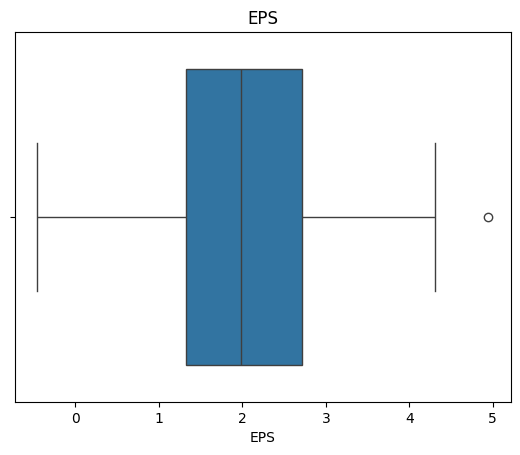

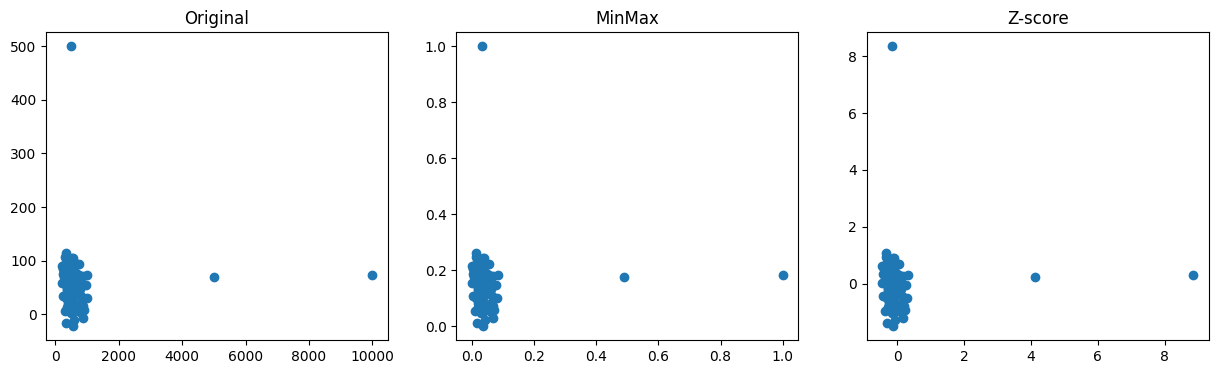

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   gio_choi       100 non-null    float64
 1   diem_tich_luy  100 non-null    float64
 2   so_level       100 non-null    int64  
 3   so_vat_pham    100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB
None
gio_choi         0
diem_tich_luy    0
so_level         0
so_vat_pham      0
dtype: int64


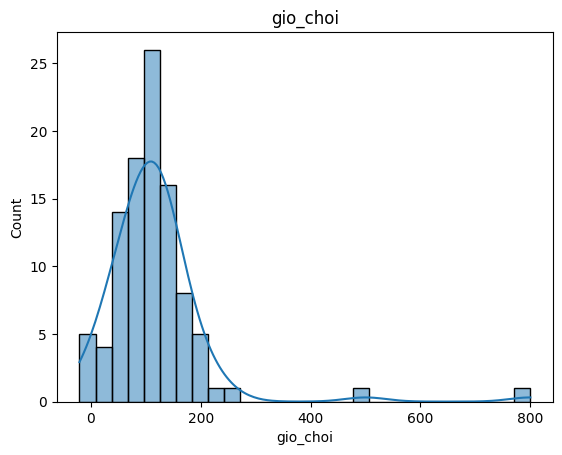

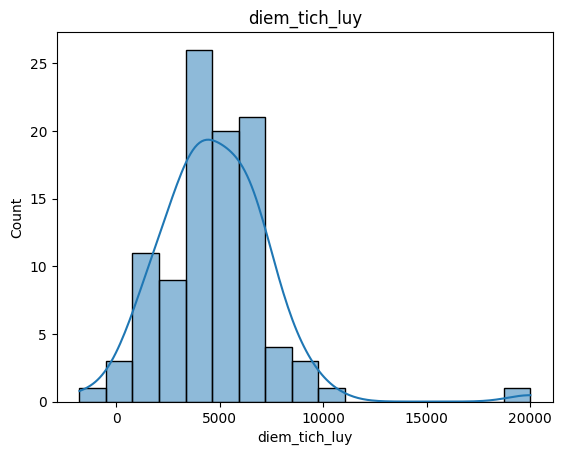

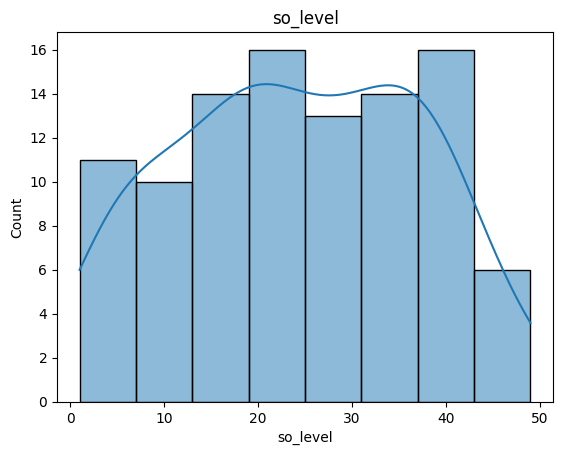

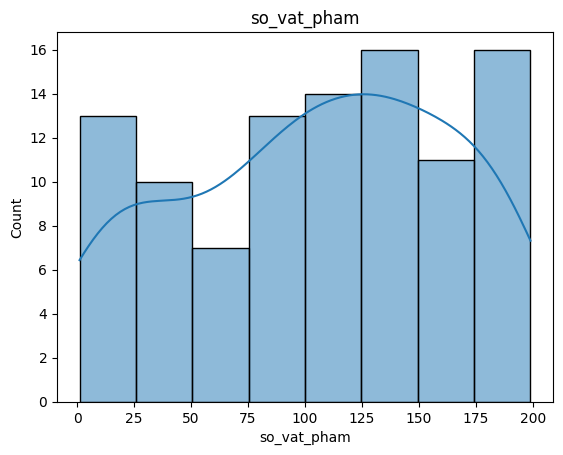

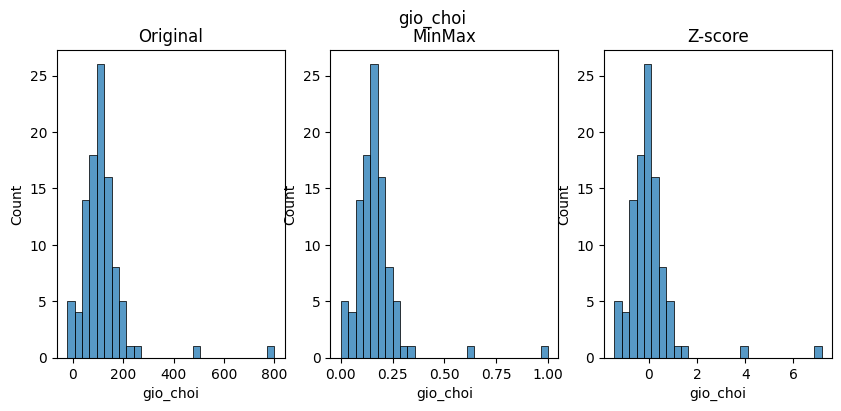

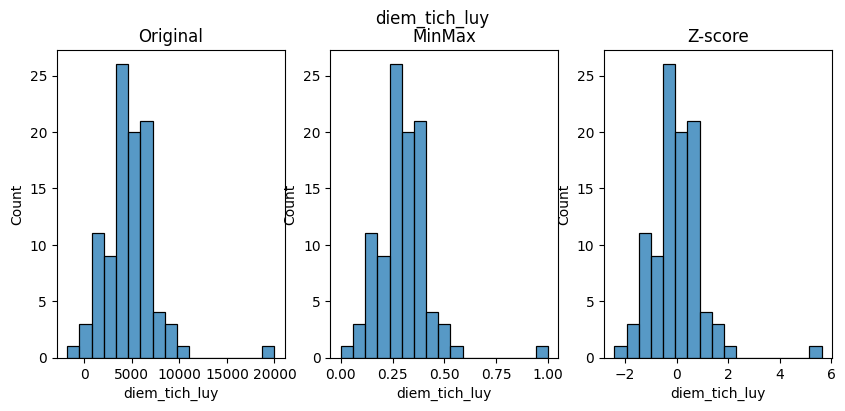

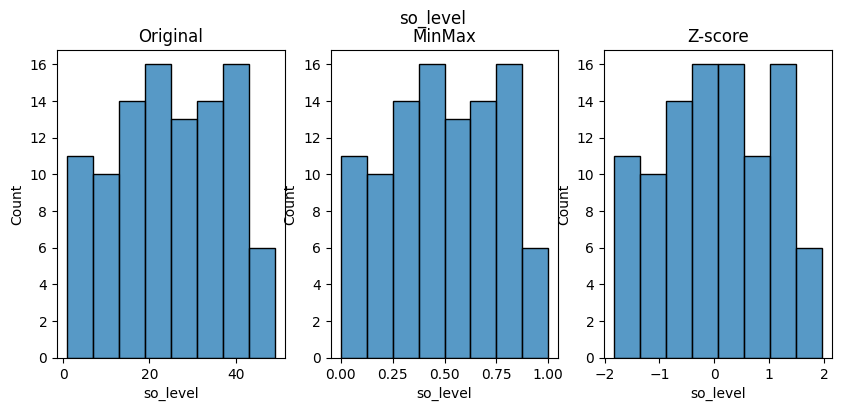

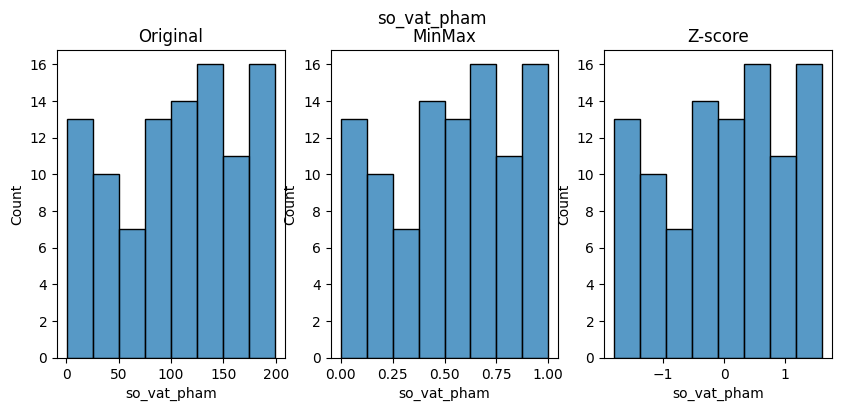

In [3]:
# Thư viện xử lý dữ liệu
import pandas as pd
import numpy as np

# Thư viện trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện chuẩn hóa dữ liệu
from sklearn.preprocessing import MinMaxScaler, StandardScaler


# ===== Bài 1 - Ý 1: Nạp dữ liệu, kiểm tra missing values, thống kê mô tả =====
df = pd.read_csv('/mnt/data/ITA105_Lab_3_Sports.csv')

print(df.info())            # thông tin dataset
print(df.isnull().sum())    # kiểm tra missing values
print(df.describe())        # thống kê mô tả

# ===== Bài 1 - Ý 2: Vẽ histogram và boxplot cho từng biến =====
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(10,4))

    # Histogram: quan sát phân phối
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram - {col}')

    # Boxplot: quan sát scale và outlier
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')

    plt.show()

# ===== Bài 1 - Ý 3: Chuẩn hóa Min-Max Scaling → [0,1] =====
scaler_mm = MinMaxScaler()
df_mm = pd.DataFrame(
    scaler_mm.fit_transform(df.select_dtypes(include=np.number)),
    columns=df.select_dtypes(include=np.number).columns
)

# ===== Bài 1 - Ý 4: Chuẩn hóa Z-Score → mean=0, std=1 =====
scaler_z = StandardScaler()
df_z = pd.DataFrame(
    scaler_z.fit_transform(df.select_dtypes(include=np.number)),
    columns=df.select_dtypes(include=np.number).columns
)

# ===== Bài 1 - Ý 5: So sánh phân phối trước và sau chuẩn hóa =====
for col in df_mm.columns:
    plt.figure(figsize=(10,4))

    sns.kdeplot(df[col], label='Original')
    sns.kdeplot(df_mm[col], label='MinMax')
    sns.kdeplot(df_z[col], label='Z-score')

    plt.title(f'Compare Distribution - {col}')
    plt.legend()
    plt.show()



# ===== Bài 2 - Ý 1: Khám phá dữ liệu, thống kê =====
df = pd.read_csv('/mnt/data/ITA105_Lab_3_Health.csv')

print(df.info())
print(df.describe())

# ===== Bài 2 - Ý 2: Trực quan hóa (histogram, boxplot) =====
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])

    plt.title(col)
    plt.show()

# ===== Bài 2 - Ý 3: Phát hiện ngoại lệ =====
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

# ===== Bài 2 - Ý 4: Chuẩn hóa bằng Min-Max và Z-Score =====
mm = MinMaxScaler()
z = StandardScaler()

df_mm = pd.DataFrame(
    mm.fit_transform(df.select_dtypes(include=np.number)),
    columns=df.select_dtypes(include=np.number).columns
)

df_z = pd.DataFrame(
    z.fit_transform(df.select_dtypes(include=np.number)),
    columns=df.select_dtypes(include=np.number).columns
)

# ===== Bài 2 - Ý 5: So sánh phân phối trước và sau chuẩn hóa =====
for col in df_mm.columns:
    plt.figure(figsize=(10,4))

    sns.kdeplot(df[col], label='Original')
    sns.kdeplot(df_mm[col], label='MinMax')
    sns.kdeplot(df_z[col], label='Z-score')

    plt.legend()
    plt.title(col)
    plt.show()

# ===== Bài 2 - Ý 6: Nhận xét (viết trong báo cáo) =====
# - Biến có nhiều outlier sẽ bị ảnh hưởng mạnh bởi Min-Max
# - Z-score ổn định hơn khi có ngoại lệ


# ===== Bài 3 - Ý 1: Khám phá dataset =====
df = pd.read_csv('/mnt/data/ITA105_Lab_3_Finance.csv')

print(df.info())
print(df.describe())

# ===== Bài 3 - Ý 2: Vẽ boxplot để quan sát scale và ngoại lệ =====
for col in df.select_dtypes(include=np.number).columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# ===== Bài 3 - Ý 3: Chuẩn hóa Min-Max và Z-Score =====
mm = MinMaxScaler()
z = StandardScaler()

df_mm = pd.DataFrame(
    mm.fit_transform(df.select_dtypes(include=np.number)),
    columns=df.select_dtypes(include=np.number).columns
)

df_z = pd.DataFrame(
    z.fit_transform(df.select_dtypes(include=np.number)),
    columns=df.select_dtypes(include=np.number).columns
)

# ===== Bài 3 - Ý 4: Scatterplot so sánh 2 biến =====
cols = df.select_dtypes(include=np.number).columns[:2]

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(df[cols[0]], df[cols[1]])
plt.title('Original')

plt.subplot(1,3,2)
plt.scatter(df_mm[cols[0]], df_mm[cols[1]])
plt.title('MinMax')

plt.subplot(1,3,3)
plt.scatter(df_z[cols[0]], df_z[cols[1]])
plt.title('Z-score')

plt.show()

# ===== Bài 3 - Ý 5: Nhận xét =====
# - Có outlier lớn → Min-Max bị nén dữ liệu mạnh
# - Z-score phù hợp hơn

# ===== Bài 3 - Ý 6: Thảo luận =====
# - Linear Regression → nên dùng Z-score
# - KNN → nên dùng Z-score để tránh lệch khoảng cách

# ===== Bài 4 - Ý 1: Khám phá dữ liệu, kiểm tra missing =====
df = pd.read_csv('/mnt/data/ITA105_Lab_3_Gaming.csv')

print(df.info())
print(df.isnull().sum())

# ===== Bài 4 - Ý 2: Trực quan hóa phân phối =====
for col in df.select_dtypes(include=np.number).columns:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

# ===== Bài 4 - Ý 3: Chuẩn hóa dữ liệu =====
mm = MinMaxScaler()
z = StandardScaler()

df_mm = pd.DataFrame(
    mm.fit_transform(df.select_dtypes(include=np.number)),
    columns=df.select_dtypes(include=np.number).columns
)

df_z = pd.DataFrame(
    z.fit_transform(df.select_dtypes(include=np.number)),
    columns=df.select_dtypes(include=np.number).columns
)

# ===== Bài 4 - Ý 4: So sánh histogram trước và sau chuẩn hóa =====
for col in df_mm.columns:
    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    sns.histplot(df[col])
    plt.title('Original')

    plt.subplot(1,3,2)
    sns.histplot(df_mm[col])
    plt.title('MinMax')

    plt.subplot(1,3,3)
    sns.histplot(df_z[col])
    plt.title('Z-score')

    plt.suptitle(col)
    plt.show()

# ===== Bài 4 - Ý 5: Thảo luận =====
# - Có người chơi "cày cuốc" → outlier lớn
# - Min-Max bị ảnh hưởng mạnh
# - Z-score phù hợp hơn

# ===== Bài 4 - Ý 6: Chuẩn bị cho mô hình =====
# - Clustering / KNN → chọn Z-score để đảm bảo khoảng cách chính xác
